# Time series forecasting: ARIMA against ML against deep learning

### Three families of forecaster, one hourly series, and a baseline that copies last week

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to split a time series without leaking, why the seasonal naive baseline is the only number that makes a forecast score readable, how ARIMA, gradient boosting and a small neural network compare on the same series at the same horizons, what happens to each of them as the horizon grows and the errors compound, and how to check whether a prediction interval covers what it claims to |
| **You should already know** | [Regression metrics](../../01-foundations/06-regression-metrics/) · [Gradient boosting](../../04-ensembles/05-gradient-boosting/) · [A training loop](../../07-neural-networks/07-a-training-loop/) |
| **Dataset** | UCI Bike Sharing, hourly hire counts for Washington DC across two years. It carries a daily cycle and a weekly cycle, both strong, which is what makes a naive baseline hard to beat |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [10-01 Autoencoders](../../10-generative-models/01-autoencoders/) |

---

## 1. The idea, and the one thing a time series changes

Every other supervised chapter in this book shuffles its rows. Cross-validation
picks folds at random, a train and test split is a random subset, and none of
that is allowed here.

The reason is not a rule of etiquette. It is that a shuffled split lets the
model see Tuesday while predicting Monday, and demand on Tuesday is informative
about demand on Monday in a way it never would be at forecast time. The number
that comes out is real arithmetic on a question nobody will ever ask.

So this chapter changes two things and keeps everything else identical to the
rest of the book. The split runs forward in time. And every model is compared
against **the seasonal naive forecast**, which says that this hour will look
like the same hour last week and does no arithmetic at all.

That baseline is the part people skip, and skipping it is why forecasting
papers are hard to read. A mean absolute error of forty on hourly bike hire
means nothing on its own. It means something the moment you know what copying
last week scores on the same hours.

I went in expecting the learned models to beat that baseline comfortably at
every horizon, because they have a calendar, a fitted seasonal structure and
two years of history, and the baseline has one week of memory. Section 5 counts
how many of them actually did, and the count was lower than I expected.

In [1]:
import sys
import time
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import HistGradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# A twenty-thousand-parameter network on seventeen thousand rows is smaller than
# the cost of moving batches to a GPU and back, so this stays on the CPU and the
# runtime is the same on any machine.
DEVICE = torch.device("cpu")

DAY = 24            # hours in the daily cycle
WEEK = 24 * 7       # hours in the weekly cycle
HORIZON = WEEK      # how far ahead the multi-step section forecasts
TEST_HOURS = 28 * DAY
VAL_HOURS = 28 * DAY
ORIGIN_STEP = 12    # hours between successive forecast origins
ARIMA_WINDOW = 120 * DAY  # trailing hours ARIMA's likelihood is fitted on
LAGS = [1, 2, 3, DAY, DAY + 1, 2 * DAY, WEEK, WEEK + 1, 2 * WEEK]
MAX_LAG = max(LAGS)
COVERAGE = 0.80     # nominal coverage every interval in section 6 claims

print(f"torch {torch.__version__} on {DEVICE}")
print(f"daily cycle {DAY} h, weekly cycle {WEEK} h, forecast horizon {HORIZON} h")
print(f"test block {TEST_HOURS} h, validation block {VAL_HOURS} h, "
      f"origins every {ORIGIN_STEP} h")

torch 2.11.0+cu128 on cpu
daily cycle 24 h, weekly cycle 168 h, forecast horizon 168 h
test block 672 h, validation block 672 h, origins every 12 h


### Rebuilding the clock

The house loader hands back the bike sharing features and the hourly count, and
it drops the calendar column because every other chapter treats this file as a
table of rows rather than as a series. A forecaster needs the clock back.

Two columns are enough to rebuild it exactly. `weekday` and `hr` together give
a position inside the week, and the difference between two consecutive
positions, taken modulo one week, is the number of hours between the two rows.
That recovers the gaps as well as the ordering, which matters because the file
is not complete: some hours are simply absent.

A seasonal model needs a regular grid, so the missing hours are filled by
linear interpolation and flagged. Nothing that was interpolated is ever scored.
It can appear in a lag feature, because at forecast time you would have the
same filled history in front of you, but it is not allowed to count as a right
or a wrong answer.

In [2]:
bike_X, bike_y = datasets.bike_sharing()
frame = bike_X.copy()
frame["cnt"] = bike_y.to_numpy()

# Position inside the week, in hours. The modulo recovers gaps of up to a week.
week_pos = frame["weekday"].to_numpy() * DAY + frame["hr"].to_numpy()
hour_index = np.concatenate([[0], np.cumsum(np.diff(week_pos) % WEEK)])

T = int(hour_index[-1]) + 1
grid = np.arange(T)
counts = np.interp(grid, hour_index, frame["cnt"].to_numpy().astype(float))
observed = np.zeros(T, dtype=bool)
observed[hour_index] = True

# The clock itself, derived from the first row's position and the hour offset.
absolute_hour = int(frame["hr"].iloc[0]) + grid
hour_of_day = absolute_hour % DAY
day_of_week = (int(frame["weekday"].iloc[0]) + absolute_hour // DAY) % 7
hour_of_week = day_of_week * DAY + hour_of_day

workingday = np.full(T, np.nan)
workingday[hour_index] = frame["workingday"].to_numpy()
workingday = pd.Series(workingday).ffill().bfill().to_numpy()

print(f"rows in the file      : {len(frame):,}")
print(f"hours the clock spans : {T:,}")
print(f"hours absent and filled: {T - len(frame):,} "
      f"({(T - len(frame)) / T:.2%} of the grid)")
print(f"reconstructed hour of day matches the file : "
      f"{bool(np.all(hour_of_day[hour_index] == frame['hr'].to_numpy()))}")
print(f"reconstructed day of week matches the file : "
      f"{bool(np.all(day_of_week[hour_index] == frame['weekday'].to_numpy()))}")

TEST_START = T - TEST_HOURS
VAL_START = T - TEST_HOURS - VAL_HOURS
print(f"\ntrain      : hours {MAX_LAG:,} to {VAL_START:,}")
print(f"validation : hours {VAL_START:,} to {TEST_START:,}  (interval calibration only)")
print(f"test       : hours {TEST_START:,} to {T:,}")
print(f"filled hours inside the test block: "
      f"{int((~observed[TEST_START:]).sum())}, excluded from every score")

rows in the file      : 17,379
hours the clock spans : 17,544
hours absent and filled: 165 (0.94% of the grid)
reconstructed hour of day matches the file : True
reconstructed day of week matches the file : True

train      : hours 336 to 16,200
validation : hours 16,200 to 16,872  (interval calibration only)
test       : hours 16,872 to 17,544
filled hours inside the test block: 2, excluded from every score


### What the series is made of

Before any model, the two cycles. Autocorrelation at a lag says how much of
today's value is already written down that many hours ago, and the lags worth
looking at are one hour, one day and one week.

In [3]:
def autocorrelation(series, lag):
    """Pearson correlation between the series and itself shifted by `lag`."""
    a, b = series[lag:], series[:-lag]
    return float(np.corrcoef(a, b)[0, 1])


train_slice = counts[:VAL_START]
acf_lags = np.arange(1, 3 * WEEK + 1)
acf = np.array([autocorrelation(train_slice, int(k)) for k in acf_lags])

print("autocorrelation on the training block")
for lag in [1, 2, DAY // 2, DAY, 2 * DAY, WEEK]:
    print(f"  lag {lag:>4} h : {autocorrelation(train_slice, lag):+.4f}")

print(f"\nstrongest autocorrelation beyond two hours sits at lag "
      f"{int(acf_lags[2:][np.argmax(acf[2:])])} h")

profile = pd.Series(train_slice).groupby(hour_of_week[:VAL_START]).mean()
print(f"busiest hour of the week: {int(profile.idxmax())} "
      f"(day {int(profile.idxmax()) // DAY}, hour {int(profile.idxmax()) % DAY}), "
      f"mean {profile.max():.1f} hires")
print(f"quietest hour of the week: {int(profile.idxmin())} "
      f"(day {int(profile.idxmin()) // DAY}, hour {int(profile.idxmin()) % DAY}), "
      f"mean {profile.min():.1f} hires")
print(f"ratio between them: {profile.max() / profile.min():.1f}x")

autocorrelation on the training block
  lag    1 h : +0.8468
  lag    2 h : +0.6009
  lag   12 h : -0.1279
  lag   24 h : +0.8206
  lag   48 h : +0.6897
  lag  168 h : +0.8806

strongest autocorrelation beyond two hours sits at lag 336 h
busiest hour of the week: 65 (day 2, hour 17), mean 544.7 hires
quietest hour of the week: 75 (day 3, hour 3), mean 4.8 hires
ratio between them: 114.2x


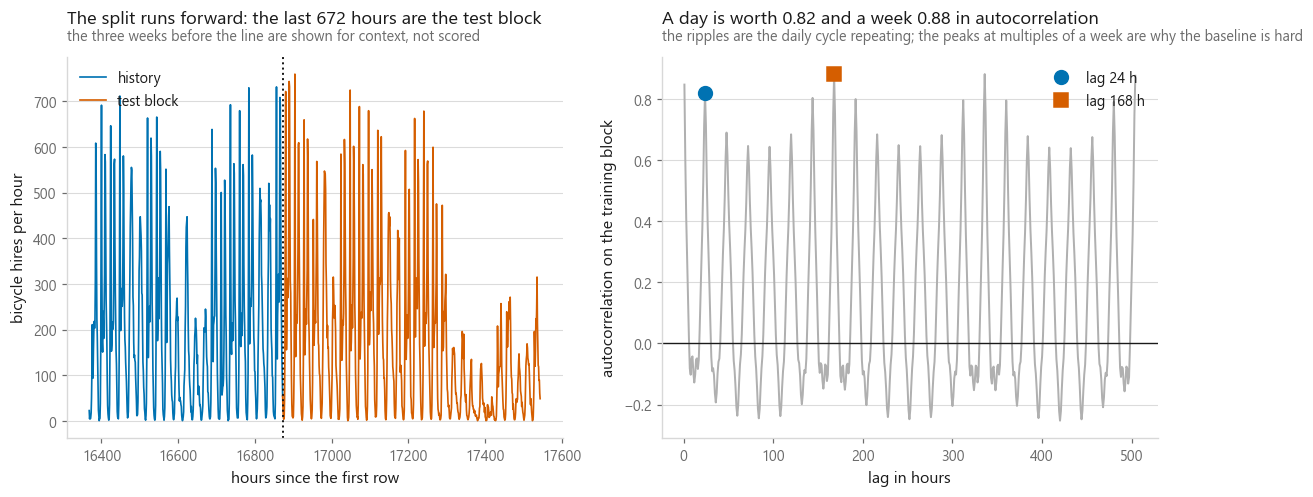

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5))

ax = axes[0]
show_from = TEST_START - 3 * WEEK
ax.plot(grid[show_from:TEST_START + 1], counts[show_from:TEST_START + 1],
        color=style.PALETTE[0], lw=1.1, label="history")
ax.plot(grid[TEST_START:], counts[TEST_START:], color=style.HIGHLIGHT, lw=1.1,
        label="test block")
ax.axvline(TEST_START, color=style.INK, ls=":", lw=1.3)
ax.set_xlabel("hours since the first row")
ax.set_ylabel("bicycle hires per hour")
ax.legend(loc="upper left")
style.title(ax, f"The split runs forward: the last {TEST_HOURS} hours are the test block",
            "the three weeks before the line are shown for context, not scored")

ax = axes[1]
ax.plot(acf_lags, acf, color=style.NEUTRAL, lw=1.3)
for lag, colour, marker in [(DAY, style.PALETTE[0], style.MARKERS[0]),
                            (WEEK, style.HIGHLIGHT, style.MARKERS[1])]:
    ax.plot([lag], [acf[lag - 1]], color=colour, marker=marker, ms=9, ls="none",
            label=f"lag {lag} h")
ax.axhline(0, color=style.INK, lw=0.9)
ax.set_xlabel("lag in hours")
ax.set_ylabel("autocorrelation on the training block")
ax.legend(loc="upper right")
style.title(ax, f"A day is worth {acf[DAY - 1]:.2f} and a week {acf[WEEK - 1]:.2f} "
                f"in autocorrelation",
            "the ripples are the daily cycle repeating; the peaks at multiples of a week are why "
            "the baseline is hard")

style.save(fig, FIG / "fig-01-the-series.png")

The right-hand panel is the whole difficulty of this chapter in one line. A
forecaster that copies the value from the same hour last week is not guessing.
It is reading off a correlation the chart puts a number on, and it costs
nothing to compute.

## 2. The maths, minimal

### ARIMA

An ARIMA(p, d, q) model has three parts and each one is a sentence.

**Differencing**, the d. Replace the series with its changes, $\nabla y_t = y_t
- y_{t-1}$, and repeat d times. This is what turns a wandering series into one
with a stable mean, which is what the rest of the model assumes.

**Autoregression**, the p. The differenced value is a weighted sum of its own
recent past:

$$\nabla^d y_t = c + \sum_{i=1}^{p} \phi_i\, \nabla^d y_{t-i} + \varepsilon_t$$

**Moving average**, the q. Add a weighted sum of the recent shocks:

$$\nabla^d y_t = c + \sum_{i=1}^{p} \phi_i\, \nabla^d y_{t-i}
                    + \sum_{j=1}^{q} \theta_j\, \varepsilon_{t-j} + \varepsilon_t$$

Everything is linear and everything looks backwards a fixed distance. That is
the model's strength, because the whole thing has a likelihood and therefore an
honest prediction interval, and it is also the limitation section 3 measures:
a stationary AR forecast decays towards the mean as the horizon grows, so it
cannot hold a daily cycle a week out unless something tells it the time.

The classical fix is a seasonal term, SARIMA, which adds the same three parts
at a seasonal lag. With a daily cycle of twenty-four hours and a weekly cycle
of a hundred and sixty-eight, one seasonal term cannot carry both, and a state
space with a hundred and sixty-eight seasonal lags in it is not something that
fits in a chapter's runtime budget. The alternative used here is the one
forecasters reach for with multiple seasonalities: keep the ARIMA errors and
hand the cycles to the model as sine and cosine regressors.

$$y_t = \beta^\top x_t + \eta_t, \qquad
  x_t \ \text{containing} \ \sin\!\Big(\frac{2\pi k t}{m}\Big),
                           \cos\!\Big(\frac{2\pi k t}{m}\Big)$$

with $\eta_t$ an ARIMA process. Both variants are fitted below, so the cost of
leaving the seasonality out is a printed number rather than an assertion.

### Scoring, and why MAE alone is not enough

Mean absolute error is in hires per hour, which is readable, and it is
meaningless without a reference. The scaled version divides by the reference:

$$\mathrm{MASE} = \frac{\mathrm{MAE}(\text{model})}{\mathrm{MAE}(\text{seasonal naive on the training block})}$$

One is the line. Below one the model is worth its compute, above one it is not,
and the number reads the same whether the series is bicycles or electricity.

In [5]:
def mae(truth, prediction, mask=None):
    error = np.abs(np.asarray(truth, dtype=float) - np.asarray(prediction, dtype=float))
    if mask is not None:
        error = error[mask]
    return float(error.mean())


def mae_se(truth, prediction, mask=None):
    """Standard error of the MAE, from the spread of the absolute errors themselves.

    A MAE is a sample mean, so it has a standard error and two MAEs closer together
    than that error are not ordered by this test set. On a few hundred hours of a
    series this spiky the error bar is larger than most people expect.
    """
    error = np.abs(np.asarray(truth, dtype=float) - np.asarray(prediction, dtype=float))
    if mask is not None:
        error = error[mask]
    return float(error.std(ddof=1) / np.sqrt(len(error)))


def rmse(truth, prediction, mask=None):
    error = (np.asarray(truth, dtype=float) - np.asarray(prediction, dtype=float)) ** 2
    if mask is not None:
        error = error[mask]
    return float(np.sqrt(error.mean()))


# The MASE denominator is fixed once, on the training block only, so every score
# in the notebook is divided by the same number.
MASE_SCALE = mae(counts[MAX_LAG:VAL_START], counts[MAX_LAG - WEEK:VAL_START - WEEK])
print(f"seasonal naive MAE on the training block: {MASE_SCALE:.3f} hires per hour")
print("every MASE below is a MAE divided by that number")

seasonal naive MAE on the training block: 50.901 hires per hour
every MASE below is a MAE divided by that number


## 3. From scratch: an AR model, and where its long forecasts go

An AR(p) fitted by least squares is four lines of NumPy, and writing it out is
worth the space for two reasons. It shows that the autoregressive part of ARIMA
is an ordinary regression of the series on shifted copies of itself. And it
lets me forecast recursively by hand and watch what happens to the forecast as
the horizon grows, which is the mechanism behind the result in section 5.

The design matrix holds one column per lag. Each row is a time, each entry is
the value that many hours earlier, and the target is the value now.

In [6]:
def ar_design(series, p):
    """Rows are times p..n-1. Column k holds y[t-k-1]. First column is the intercept."""
    n = len(series)
    columns = [np.ones(n - p)] + [series[p - k:n - k] for k in range(1, p + 1)]
    return np.column_stack(columns), series[p:]


def ar_fit(series, p):
    design, target = ar_design(series, p)
    beta, *_ = np.linalg.lstsq(design, target, rcond=None)
    return beta[0], beta[1:]


def ar_forecast(history, intercept, phi, horizon):
    """Recursive multi-step: each prediction becomes an input to the next one."""
    p = len(phi)
    buffer = list(history[-p:])
    out = []
    for _ in range(horizon):
        nxt = intercept + float(np.dot(phi, buffer[::-1]))
        out.append(nxt)
        buffer = buffer[1:] + [nxt]
    return np.array(out)


P_AR = 3
scratch_c, scratch_phi = ar_fit(counts[:VAL_START], P_AR)

# Parity check one: the same normal equations, solved by statsmodels' regression
# code rather than mine.
from statsmodels.regression.linear_model import OLS

design, target = ar_design(counts[:VAL_START], P_AR)
ols = OLS(target, design).fit()
print(f"AR({P_AR}) by my normal equations vs statsmodels OLS, max abs difference: "
      f"{np.max(np.abs(ols.params - np.concatenate([[scratch_c], scratch_phi]))):.3e}")

# Parity check two: the same model estimated by exact maximum likelihood. These
# two do not have to agree, and the gap is the point.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mle = ARIMA(counts[:VAL_START], order=(P_AR, 0, 0), trend="c").fit(
        method_kwargs={"maxiter": 100, "disp": False})

mle_phi = np.asarray(mle.arparams)
mle_mean = float(np.asarray(mle.params)[0])
mle_intercept = mle_mean * (1.0 - mle_phi.sum())
print(f"\nAR coefficients, least squares : {np.round(scratch_phi, 5)}")
print(f"AR coefficients, exact MLE     : {np.round(mle_phi, 5)}")
print(f"implied intercept, least squares: {scratch_c:.4f}")
print(f"implied intercept, exact MLE    : {mle_intercept:.4f}")
print("the two estimators are not the same estimator, so a small gap here is "
      "correct rather than a bug")

AR(3) by my normal equations vs statsmodels OLS, max abs difference: 6.395e-14



AR coefficients, least squares : [ 1.26921 -0.6284   0.18249]
AR coefficients, exact MLE     : [ 1.26919 -0.62836  0.18248]
implied intercept, least squares: 33.2431
implied intercept, exact MLE    : 33.2370
the two estimators are not the same estimator, so a small gap here is correct rather than a bug


Now the part that matters for section 5. Take the fitted AR, start it at a real
point in the series, and let it forecast one hour at a time, feeding each
prediction back in as the input to the next. A stationary AR has no memory of
the calendar, so there is only one place its forecast can go.

In [7]:
origin_demo = VAL_START
path = ar_forecast(counts[:origin_demo], scratch_c, scratch_phi, HORIZON)
train_mean = float(counts[:VAL_START].mean())
distance = np.abs(path - train_mean)

print(f"training mean: {train_mean:.2f} hires per hour")
print(f"\nAR({P_AR}) forecast, distance from the training mean")
for h in [1, 6, 12, DAY, 2 * DAY, WEEK]:
    print(f"  {h:>4} h ahead : forecast {path[h - 1]:8.2f}   "
          f"distance {distance[h - 1]:7.2f}")
closer = np.flatnonzero(distance < distance[0] / 2)
half_life = int(closer[0] + 1) if closer.size else None
print(f"\nthe forecast is halfway to the mean after "
      f"{half_life if half_life else 'more than ' + str(HORIZON)} h, and by "
      f"{HORIZON} h it sits {distance[-1]:.3f} away from it")
print(f"the actual series over the same window moved between "
      f"{counts[origin_demo:origin_demo + HORIZON].min():.0f} and "
      f"{counts[origin_demo:origin_demo + HORIZON].max():.0f} hires")

training mean: 188.10 hires per hour

AR(3) forecast, distance from the training mean
     1 h ahead : forecast    55.98   distance  132.12
     6 h ahead : forecast   161.31   distance   26.79
    12 h ahead : forecast   183.02   distance    5.08
    24 h ahead : forecast   187.95   distance    0.15
    48 h ahead : forecast   188.13   distance    0.03
   168 h ahead : forecast   188.13   distance    0.03

the forecast is halfway to the mean after 3 h, and by 168 h it sits 0.032 away from it
the actual series over the same window moved between 2 and 724 hires


That is the whole problem with a plain ARIMA on a seasonal series, stated by
its own arithmetic. Past the printed half-life the forecast is a horizontal
line through the mean, while the series it is predicting keeps swinging between
the two extremes printed above it. Nothing is broken. A model that only knows
how to extrapolate its own recent past runs out of recent past.

## 4. In practice: three families on one series

Every model below sees the same history, is fitted on the same training block,
and is scored on the same hours. The differences are the ones in the section
heading and nothing else.

### The features, and one leakage check

The gradient booster and the neural network both take the same feature vector:
a set of lags, two rolling summaries, and the calendar encoded as sines and
cosines. Writing one function and using it for both training and forecasting is
the thing that stops the two from drifting apart, which is the most common way
a forecasting pipeline quietly starts cheating.

The check below poisons the future with `nan` and asks whether any feature
notices. If a feature at hour t reads anything from hour t or later, it comes
back as `nan` and the check fails.

In [8]:
FOURIER_ORDERS = [(DAY, 3), (WEEK, 2)]


def fourier_terms(t, period, order):
    return np.column_stack([f(2 * np.pi * k * t / period)
                            for k in range(1, order + 1) for f in (np.sin, np.cos)])


FOURIER = np.column_stack([fourier_terms(grid, period, order)
                           for period, order in FOURIER_ORDERS])

FEATURE_NAMES = ([f"lag {k}" for k in LAGS]
                 + ["mean of the last day", "same hour, previous two weeks"]
                 + ["sin hour", "cos hour", "sin half-day", "cos half-day",
                    "sin weekday", "cos weekday", "working day"])


def features_at(history, times):
    """Feature rows for `times`, read only from strictly earlier hours.

    `history` has shape (n, T) and `times` shape (n,), so the same function
    serves training, where every row shares one history, and recursive
    forecasting, where each row has its own history with predictions written
    into it.
    """
    rows = np.arange(history.shape[0])
    columns = [history[rows, times - lag] for lag in LAGS]
    columns.append(np.mean([history[rows, times - k] for k in range(1, DAY + 1)], axis=0))
    columns.append(0.5 * (history[rows, times - WEEK] + history[rows, times - 2 * WEEK]))
    hod, dow = hour_of_day[times], day_of_week[times]
    columns += [np.sin(2 * np.pi * hod / DAY), np.cos(2 * np.pi * hod / DAY),
                np.sin(4 * np.pi * hod / DAY), np.cos(4 * np.pi * hod / DAY),
                np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7),
                workingday[times]]
    return np.column_stack(columns)


def rows_for(times):
    """Training-time features: one shared history, broadcast without copying it."""
    times = np.asarray(times)
    return features_at(np.broadcast_to(counts, (len(times), T)), times)


poisoned = counts.copy()
probe = TEST_START + 100
poisoned[probe:] = np.nan
probe_row = features_at(np.broadcast_to(poisoned, (1, T)), np.array([probe]))
print(f"{len(FEATURE_NAMES)} features per row")
print(f"a feature at hour {probe:,} reads something from hour {probe:,} or later: "
      f"{bool(np.isnan(probe_row).any())}")

train_times = np.arange(MAX_LAG, VAL_START)
val_times = np.arange(VAL_START, TEST_START)
test_times = np.arange(TEST_START, T)
X_train, y_train = rows_for(train_times), counts[train_times]
X_val, y_val = rows_for(val_times), counts[val_times]
X_test, y_test = rows_for(test_times), counts[test_times]
test_mask = observed[test_times]
print(f"training rows {len(train_times):,}, validation rows {len(val_times):,}, "
      f"test rows {len(test_times):,} of which {int(test_mask.sum()):,} are scored")

18 features per row
a feature at hour 16,972 reads something from hour 16,972 or later: False
training rows 15,864, validation rows 672, test rows 672 of which 670 are scored


### Gradient boosting

One line in this cell is worth stopping on. `early_stopping` defaults to `auto`
in scikit-learn, which switches itself on above ten thousand rows and carves
out a **random** validation slice to decide when to stop. On a time series that
slice is scattered through the future, so the stopping rule is chosen using
rows the model is about to be asked to predict. It is turned off here, and a
fixed iteration count is used instead.

In [9]:
GBM_SETTINGS = dict(max_iter=300, learning_rate=0.08, max_leaf_nodes=31,
                    min_samples_leaf=40, early_stopping=False, random_state=SEED)

started = time.perf_counter()
gbm = HistGradientBoostingRegressor(**GBM_SETTINGS).fit(X_train, y_train)
gbm_low = HistGradientBoostingRegressor(loss="quantile",
                                        quantile=(1 - COVERAGE) / 2,
                                        **GBM_SETTINGS).fit(X_train, y_train)
gbm_high = HistGradientBoostingRegressor(loss="quantile",
                                         quantile=1 - (1 - COVERAGE) / 2,
                                         **GBM_SETTINGS).fit(X_train, y_train)
print(f"three gradient boosters fitted in {time.perf_counter() - started:.1f} s "
      f"(the mean, and one for each end of the interval)")

three gradient boosters fitted in 7.7 s (the mean, and one for each end of the interval)


### A small neural network

Same features, same target, same training rows. The only preprocessing
difference is standardisation, which trees do not need and a network does. The
architecture is deliberately unremarkable, because the question this chapter
asks is what a neural model buys on a series of this size, and a bigger network
would answer a different question.

In [10]:
x_mean, x_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
y_mean, y_std = y_train.mean(), y_train.std()


def standardise(rows):
    return torch.tensor((rows - x_mean) / x_std, dtype=torch.float32, device=DEVICE)


net = nn.Sequential(
    nn.Linear(X_train.shape[1], 96), nn.ReLU(),
    nn.Linear(96, 48), nn.ReLU(),
    nn.Linear(48, 1),
).to(DEVICE)

optimiser = torch.optim.Adam(net.parameters(), lr=2e-3)
loss_fn = nn.MSELoss()
Xt = standardise(X_train)
yt = torch.tensor((y_train - y_mean) / y_std, dtype=torch.float32, device=DEVICE).unsqueeze(1)

EPOCHS, BATCH = 60, 512
generator = torch.Generator().manual_seed(SEED)
started = time.perf_counter()
for epoch in range(EPOCHS):
    order = torch.randperm(len(Xt), generator=generator)
    for begin in range(0, len(order), BATCH):
        batch = order[begin:begin + BATCH]
        optimiser.zero_grad()
        loss_fn(net(Xt[batch]), yt[batch]).backward()
        optimiser.step()
net.eval()
print(f"network: {sum(p.numel() for p in net.parameters()):,} parameters, "
      f"{EPOCHS} epochs in {time.perf_counter() - started:.1f} s")


def mlp_predict(rows):
    with torch.no_grad():
        return net(standardise(rows)).squeeze(-1).cpu().numpy() * y_std + y_mean

network: 6,529 parameters, 60 epochs in 3.8 s


### ARIMA, twice

Once as the model everybody writes first, with no seasonal information at all,
and once with the daily and weekly cycles handed to it as sine and cosine
regressors. Both are fitted on a trailing window of the training block rather
than on all of it, because the likelihood is evaluated by a Kalman filter over
every observation and the fit has to stay inside the chapter's runtime.

In [11]:
arima_slice = slice(VAL_START - ARIMA_WINDOW, VAL_START)
ARIMA_ORDER = (2, 1, 2)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    started = time.perf_counter()
    arima_plain = ARIMA(counts[arima_slice], order=ARIMA_ORDER, trend="n").fit(
        method_kwargs={"maxiter": 100, "disp": False})
    plain_seconds = time.perf_counter() - started

    started = time.perf_counter()
    arima_fourier = ARIMA(counts[arima_slice], order=ARIMA_ORDER,
                          exog=FOURIER[arima_slice], trend="n").fit(
        method_kwargs={"maxiter": 100, "disp": False})
    fourier_seconds = time.perf_counter() - started

print(f"ARIMA{ARIMA_ORDER} on {ARIMA_WINDOW:,} trailing hours")
print(f"  plain            : {plain_seconds:.1f} s, "
      f"converged {arima_plain.mle_retvals.get('converged')}, "
      f"AIC {arima_plain.aic:,.0f}")
print(f"  + {FOURIER.shape[1]} Fourier terms: {fourier_seconds:.1f} s, "
      f"converged {arima_fourier.mle_retvals.get('converged')}, "
      f"AIC {arima_fourier.aic:,.0f}")


def arima_at(fitted, exog, start, length):
    """Run the already-fitted parameters over a window, without re-estimating them.

    With `length=0` the window stops at `start`, which is what a forecast origin
    needs. With `length` set to the test block, the filter runs through the test
    data as well, which is only used for one-step-ahead prediction: the Kalman
    filter's estimate at hour t conditions on hours up to t-1, and no parameter
    ever sees a test row.
    """
    window = slice(start - ARIMA_WINDOW, start + length)
    if exog is None:
        return fitted.apply(counts[window], refit=False)
    return fitted.apply(counts[window], exog=FOURIER[window], refit=False)

ARIMA(2, 1, 2) on 2,880 trailing hours
  plain            : 1.0 s, converged True, AIC 35,710
  + 10 Fourier terms: 3.8 s, converged True, AIC 34,750


### One hour ahead

The easiest question a forecaster is ever asked, and the one most papers
report. Every model gets the true history up to the hour before, and predicts
the next hour. The four baselines do no fitting at all.

In [12]:
climatology = (pd.Series(counts[MAX_LAG:VAL_START])
               .groupby(hour_of_week[MAX_LAG:VAL_START]).mean()
               .reindex(range(WEEK)).to_numpy())

print("one hour ahead on the validation block, before anything is scored on test")
print(f"  gradient boosting : {mae(y_val, gbm.predict(X_val)):.3f}")
print(f"  neural network    : {mae(y_val, mlp_predict(X_val)):.3f}")
print(f"  seasonal naive    : {mae(y_val, counts[val_times - WEEK]):.3f}")

one_step = {
    "naive, last hour": counts[test_times - 1],
    "seasonal naive, last day": counts[test_times - DAY],
    "seasonal naive, last week": counts[test_times - WEEK],
    "hour-of-week mean": climatology[hour_of_week[test_times]],
    "ARIMA(2,1,2)": None,
    "ARIMA(2,1,2) + Fourier": None,
    "gradient boosting": np.maximum(gbm.predict(X_test), 0.0),
    "neural network": np.maximum(mlp_predict(X_test), 0.0),
}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    applied_plain = arima_at(arima_plain, None, TEST_START, len(test_times))
    applied_fourier = arima_at(arima_fourier, FOURIER, TEST_START, len(test_times))
one_step["ARIMA(2,1,2)"] = np.maximum(
    np.asarray(applied_plain.get_prediction(
        start=ARIMA_WINDOW, end=ARIMA_WINDOW + len(test_times) - 1).predicted_mean), 0.0)
one_step["ARIMA(2,1,2) + Fourier"] = np.maximum(
    np.asarray(applied_fourier.get_prediction(
        start=ARIMA_WINDOW, end=ARIMA_WINDOW + len(test_times) - 1).predicted_mean), 0.0)

BASELINE = "seasonal naive, last week"
board = pd.DataFrame([
    {"model": name,
     "MAE": mae(y_test, pred, test_mask),
     "MAE se": mae_se(y_test, pred, test_mask),
     "RMSE": rmse(y_test, pred, test_mask),
     "MASE": mae(y_test, pred, test_mask) / MASE_SCALE}
    for name, pred in one_step.items()
]).sort_values("MAE").reset_index(drop=True)
baseline_mae = float(board.loc[board["model"] == BASELINE, "MAE"].iloc[0])
board["beats the baseline"] = board["MAE"] < baseline_mae

print(board.round(4).to_string(index=False))

learned = board[~board["model"].str.contains("naive|mean")]
print(f"\nbaseline: {BASELINE}, MAE {baseline_mae:.4f}")
print(f"models that beat it one hour ahead: "
      f"{int(learned['beats the baseline'].sum())} of {len(learned)}")
print(f"best model overall: {board.loc[0, 'model']} at MAE {board.loc[0, 'MAE']:.4f}, "
      f"MASE {board.loc[0, 'MASE']:.4f}")

# A MAE is a sample mean over 670 hours, so the top of that table needs checking
# against its own error bar before it can be read as an ordering.
top, second = board.loc[0], board.loc[1]
gap = second["MAE"] - top["MAE"]
combined = float(np.sqrt(top["MAE se"] ** 2 + second["MAE se"] ** 2))
print(f"\ntop two are {top['model']} and {second['model']}")
print(f"  MAE gap {gap:.4f}, standard error of that gap {combined:.4f} -> "
      f"{'separated' if gap > 2 * combined else 'not separated by this test block'}")
print(f"  and the two metrics disagree: RMSE puts "
      f"{board.loc[board['RMSE'].idxmin(), 'model']} first")

one hour ahead on the validation block, before anything is scored on test
  gradient boosting : 26.263
  neural network    : 26.655
  seasonal naive    : 82.252
                    model     MAE  MAE se     RMSE   MASE  beats the baseline
        gradient boosting 21.0281  1.0294  33.9273 0.4131                True
           neural network 21.7334  0.9272  32.3641 0.4270                True
 seasonal naive, last day 54.4567  2.8326  91.2879 1.0699                True
   ARIMA(2,1,2) + Fourier 55.7015  2.3527  82.4968 1.0943                True
         naive, last hour 57.5209  3.0116  96.8314 1.1301                True
             ARIMA(2,1,2) 61.9838  2.3737  87.2441 1.2177                True
seasonal naive, last week 62.8806  3.4981 110.1836 1.2354               False
        hour-of-week mean 70.7203  3.3781 112.4093 1.3894               False

baseline: seasonal naive, last week, MAE 62.8806
models that beat it one hour ahead: 4 of 4
best model overall: gradient boosting at MAE

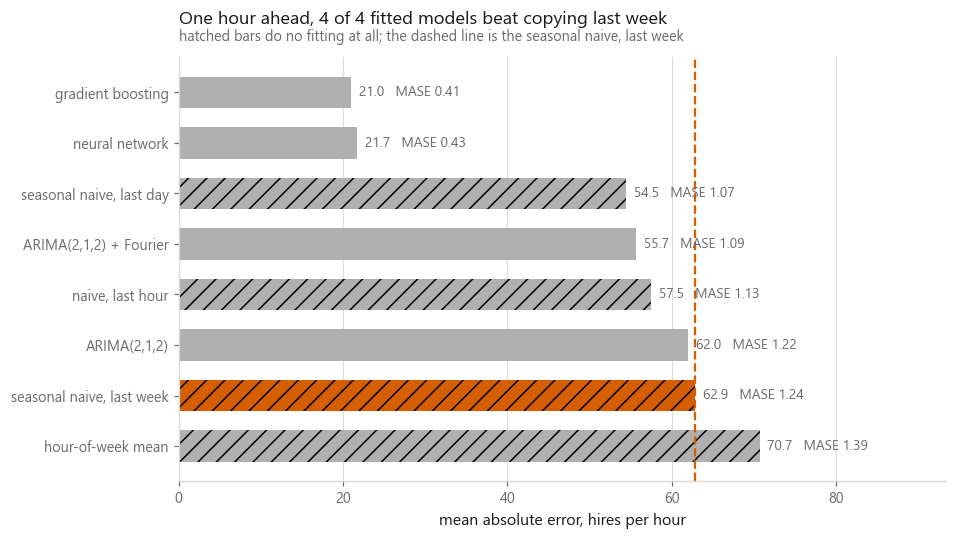

In [13]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
ordered = board.sort_values("MAE", ascending=False).reset_index(drop=True)
colours = [style.HIGHLIGHT if name == BASELINE else style.NEUTRAL
           for name in ordered["model"]]
hatches = ["//" if "naive" in name or "mean" in name else "" for name in ordered["model"]]
bars = ax.barh(np.arange(len(ordered)), ordered["MAE"], color=colours, hatch=hatches,
               height=0.62)
for y, (value, scaled) in enumerate(zip(ordered["MAE"], ordered["MASE"])):
    ax.annotate(f"{value:.1f}   MASE {scaled:.2f}", xy=(value, y), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=9, color=style.MUTED)
ax.axvline(baseline_mae, color=style.HIGHLIGHT, ls="--", lw=1.5)
ax.set_yticks(np.arange(len(ordered)), ordered["model"])
ax.set_xlim(0, ordered["MAE"].max() * 1.32)
ax.set_xlabel("mean absolute error, hires per hour")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
style.title(ax, f"One hour ahead, {int(learned['beats the baseline'].sum())} of "
                f"{len(learned)} fitted models beat copying last week",
            f"hatched bars do no fitting at all; the dashed line is the {BASELINE}")
style.save(fig, FIG / "fig-02-one-step-against-the-baseline.png")

One hour ahead is the horizon at which nothing is difficult, because the answer
is mostly already on the previous row. Read the naive row in that table before
reading anything else. Whatever the fitted models achieved, the question is how
much of it was available for free.

Then read the top of the table with the printed error bar in hand. **Gradient
boosting and the neural network are one result here, not two.** Their MAEs are
close enough that a few hundred hours of held-out data cannot order them, and the
two metrics do not even agree on the direction: MAE puts one first and RMSE puts
the other first. That is what a tie looks like when you have two summaries of the
same error distribution. RMSE squares the errors before averaging, so it is moved
by the worst hours, and MAE is not. When your two metrics disagree, the models
differ in the shape of their mistakes rather than in the size of them.

So the choice between those two is not a modelling question, it is an operational
one. Pick on fit time, on whether you can explain the model, on whether the
library will still exist in three years. And if the cost of a very bad hour is
worse than proportional, which for a bike depot it usually is, pick on RMSE and
say so before you look at the table. [The scoreboard](../../12-putting-it-together/01-the-scoreboard/)
makes the same argument on tabular data, where half the orderings it prints also
fail to survive their own noise.

The gap between either of them and the baseline, by contrast, is enormous, many
times the error bar in the printed column. That comparison is the one this section
is actually for.

## 5. Multi-step, where the errors compound

A forecast one hour ahead is almost never what anyone wants. Deciding how many
bicycles to move overnight is a question about tomorrow, and staffing is a
question about next week.

So the evaluation changes shape. From each of a series of origins spread
through the test block, every model produces a forecast for the next week of
hours, and is scored separately at each horizon. The learned models forecast
**recursively**: the prediction for one hour becomes an input to the prediction
for the next, which is where the compounding comes from.

The seasonal naive baseline does not compound, and that is the whole reason it
is dangerous. Its answer for any hour inside the next week is a real observed
number, not a prediction built on a prediction. It is exactly as good at a
hundred and sixty-eight hours as it is at one.

In [14]:
def origins_in(start, stop):
    last = stop - HORIZON
    return np.arange(start, last + 1, ORIGIN_STEP)


val_origins = origins_in(VAL_START, TEST_START)
test_origins = origins_in(TEST_START, T)
print(f"validation origins {len(val_origins)}, test origins {len(test_origins)}, "
      f"each forecasting {HORIZON} h")


def seasonal_naive_paths(origins, period):
    steps = np.arange(HORIZON)
    back = period * (steps // period + 1)
    return counts[origins[:, None] + steps[None, :] - back[None, :]]


def climatology_paths(origins):
    steps = np.arange(HORIZON)
    return climatology[hour_of_week[origins[:, None] + steps[None, :]]]


def recursive_paths(predict, origins):
    """Roll every origin forward together, writing each prediction back into its own history."""
    history = np.tile(counts, (len(origins), 1))
    history[:, origins.min():] = np.nan          # the future is not available
    for j, origin in enumerate(origins):
        history[j, :origin] = counts[:origin]    # give each origin its own real past
    out = np.zeros((len(origins), HORIZON))
    for step in range(HORIZON):
        times = origins + step
        prediction = np.maximum(predict(features_at(history, times)), 0.0)
        history[np.arange(len(origins)), times] = prediction
        out[:, step] = prediction
    return out


def arima_paths(fitted, exog, origins):
    mean = np.zeros((len(origins), HORIZON))
    lower = np.zeros_like(mean)
    upper = np.zeros_like(mean)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for j, origin in enumerate(origins):
            applied = arima_at(fitted, exog, origin, 0)
            future = slice(origin, origin + HORIZON)
            forecast = (applied.get_forecast(steps=HORIZON, exog=FOURIER[future])
                        if exog is not None else applied.get_forecast(steps=HORIZON))
            interval = np.asarray(forecast.conf_int(alpha=1 - COVERAGE))
            mean[j] = np.maximum(np.asarray(forecast.predicted_mean), 0.0)
            lower[j] = np.maximum(interval[:, 0], 0.0)
            upper[j] = np.maximum(interval[:, 1], 0.0)
    return mean, lower, upper


def all_paths(origins):
    plain_mean, plain_low, plain_high = arima_paths(arima_plain, None, origins)
    four_mean, four_low, four_high = arima_paths(arima_fourier, FOURIER, origins)
    paths = {
        "naive, last hour": np.repeat(counts[origins - 1][:, None], HORIZON, axis=1),
        "seasonal naive, last day": seasonal_naive_paths(origins, DAY),
        "seasonal naive, last week": seasonal_naive_paths(origins, WEEK),
        "hour-of-week mean": climatology_paths(origins),
        "ARIMA(2,1,2)": plain_mean,
        "ARIMA(2,1,2) + Fourier": four_mean,
        "gradient boosting": recursive_paths(gbm.predict, origins),
        "neural network": recursive_paths(mlp_predict, origins),
    }
    bands = {"ARIMA(2,1,2)": (plain_low, plain_high),
             "ARIMA(2,1,2) + Fourier": (four_low, four_high)}
    return paths, bands


started = time.perf_counter()
val_paths, val_bands = all_paths(val_origins)
test_paths, test_bands = all_paths(test_origins)
print(f"{2 * (len(val_origins) + len(test_origins))} ARIMA rollouts and "
      f"{2 * (len(val_origins) + len(test_origins))} recursive rollouts "
      f"in {time.perf_counter() - started:.1f} s")

steps = np.arange(HORIZON)
test_truth = counts[test_origins[:, None] + steps[None, :]]
test_seen = observed[test_origins[:, None] + steps[None, :]]
val_truth = counts[val_origins[:, None] + steps[None, :]]
val_seen = observed[val_origins[:, None] + steps[None, :]]
print(f"forecast points scored on test: {int(test_seen.sum()):,} of {test_seen.size:,}")


def mae_by_horizon(paths, truth, seen):
    error = np.abs(paths - truth)
    return np.array([error[:, h][seen[:, h]].mean() for h in range(HORIZON)])


curves = {name: mae_by_horizon(paths, test_truth, test_seen)
          for name, paths in test_paths.items()}
base_curve = curves[BASELINE]

table = pd.DataFrame({"horizon (h)": [1, 6, 12, DAY, 2 * DAY, 3 * DAY, WEEK]})
for name, curve in curves.items():
    table[name] = [curve[h - 1] for h in table["horizon (h)"]]
print("\nmean absolute error by horizon")
print(table.round(1).to_string(index=False))


def gives_up_at(curve):
    """First horizon at which the model no longer beats the seasonal naive baseline."""
    worse = np.flatnonzero(curve >= base_curve)
    return int(worse[0] + 1) if worse.size else None


verdicts = []
for name, curve in curves.items():
    if name == BASELINE:
        continue
    crossing = gives_up_at(curve)
    verdicts.append({
        "model": name,
        "MAE at 1 h": curve[0],
        f"MAE at {DAY} h": curve[DAY - 1],
        f"MAE at {WEEK} h": curve[WEEK - 1],
        "beats the baseline until": "never" if crossing == 1 else (
            f"{crossing} h" if crossing else f"past {HORIZON} h"),
    })
verdicts = pd.DataFrame(verdicts)
print("\n" + verdicts.round(1).to_string(index=False))

survivors = [name for name, curve in curves.items()
             if name != BASELINE and curve[WEEK - 1] < base_curve[WEEK - 1]]
fitted_names = [n for n in curves if "naive" not in n and "mean" not in n]
fitted_survivors = [n for n in survivors if n in fitted_names]
print(f"\nat {WEEK} h the baseline scores {base_curve[WEEK - 1]:.2f}")
print(f"models of any kind still under it: {len(survivors)} of {len(curves) - 1}")
print(f"fitted models still under it     : {len(fitted_survivors)} of {len(fitted_names)}")
print(f"error growth from 1 h to {WEEK} h:")
for name in fitted_names + [BASELINE]:
    curve = curves[name]
    print(f"  {name:<24} {curve[0]:7.2f} -> {curve[WEEK - 1]:7.2f}   "
          f"{curve[WEEK - 1] / curve[0]:5.2f}x")

validation origins 43, test origins 43, each forecasting 168 h


172 ARIMA rollouts and 172 recursive rollouts in 5.9 s
forecast points scored on test: 7,196 of 7,224

mean absolute error by horizon
 horizon (h)  naive, last hour  seasonal naive, last day  seasonal naive, last week  hour-of-week mean  ARIMA(2,1,2)  ARIMA(2,1,2) + Fourier  gradient boosting  neural network
           1              43.7                      48.7                       50.8               41.7          50.4                    31.3               14.0            16.1
           6             159.1                      59.6                       55.4               55.8         232.6                    79.1               55.8            55.8
          12             131.3                      45.7                       46.2               40.0         134.1                    54.0               35.9            44.4
          24              45.6                      45.6                       44.1               39.6         138.1                    56.7               42.6   

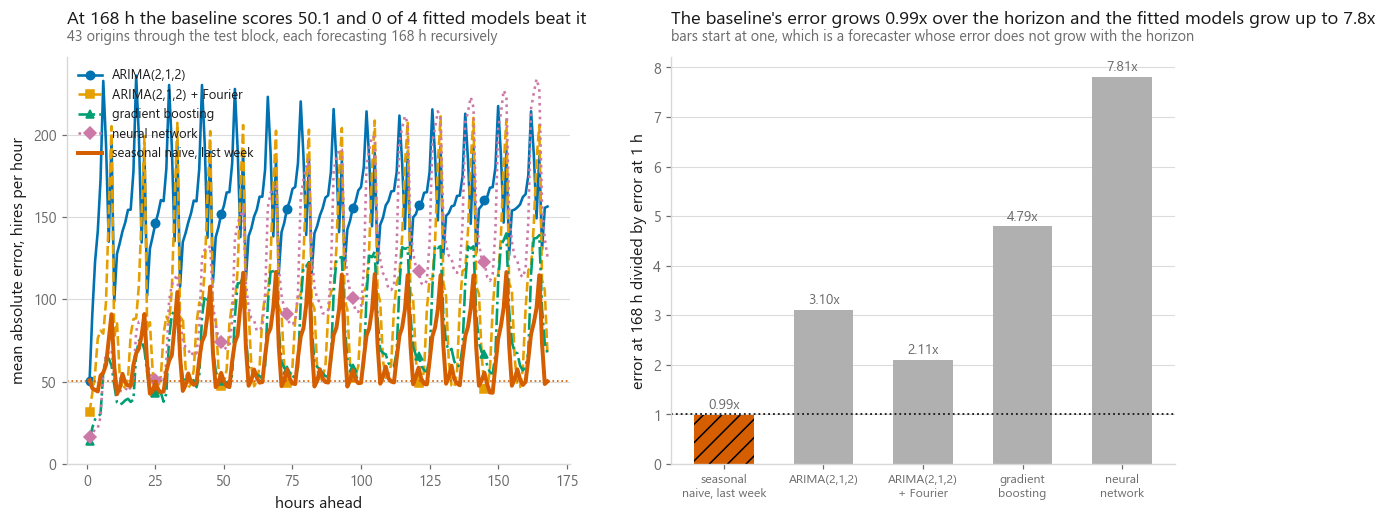

In [15]:
# PALETTE[3] is the same vermillion as HIGHLIGHT, which is reserved for the
# baseline everywhere in this notebook, so the fitted series skip it.
SERIES_COLOURS = [style.PALETTE[0], style.PALETTE[1], style.PALETTE[2], style.PALETTE[4]]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax = axes[0]
for i, name in enumerate(fitted_names):
    ax.plot(steps + 1, curves[name], color=SERIES_COLOURS[i % len(SERIES_COLOURS)],
            ls=style.DASHES[i], marker=style.MARKERS[i], markevery=24, lw=1.7, label=name)
ax.plot(steps + 1, base_curve, color=style.HIGHLIGHT, lw=2.6, label=BASELINE)
ax.axhline(base_curve[WEEK - 1], color=style.HIGHLIGHT, ls=":", lw=1.1)
ax.set_xlabel("hours ahead")
ax.set_ylabel("mean absolute error, hires per hour")
ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=8.5)
style.title(ax, f"At {WEEK} h the baseline scores {base_curve[WEEK - 1]:.1f} and "
                f"{len(fitted_survivors)} of {len(fitted_names)} fitted models beat it",
            f"{len(test_origins)} origins through the test block, each forecasting {HORIZON} h "
            f"recursively")

ax = axes[1]
names = [BASELINE] + fitted_names
grow = [curves[n][WEEK - 1] / curves[n][0] for n in names]
colours = [style.HIGHLIGHT if n == BASELINE else style.NEUTRAL for n in names]
hatch = ["//" if n == BASELINE else "" for n in names]
ax.bar(np.arange(len(names)), grow, color=colours, hatch=hatch, width=0.6)
for x, value in enumerate(grow):
    ax.annotate(f"{value:.2f}x", xy=(x, value), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9, color=style.MUTED)
ax.axhline(1.0, color=style.INK, ls=":", lw=1.2)
ax.set_xticks(np.arange(len(names)), [n.replace(" ", "\n", 1) for n in names], fontsize=8)
ax.set_ylabel(f"error at {WEEK} h divided by error at 1 h")
style.title(ax, f"The baseline's error grows {grow[0]:.2f}x over the horizon and the "
                f"fitted models grow up to {max(grow[1:]):.1f}x",
            "bars start at one, which is a forecaster whose error does not grow with the horizon")

style.save(fig, FIG / "fig-03-error-by-horizon.png")

The left panel is the chapter. Read across it and find the horizon at which
each curve crosses the flat line, then read the same crossings out of the
printed table above, which names them in hours.

The mechanism is the one section 3 measured by hand. A recursive forecaster is
applied to its own output, so a small bias at one hour becomes an input at the
next, and the model has no way to notice. The seasonal naive forecast never
does that. Every number it produces for the coming week was measured, not
predicted, and its error at the end of the week is the same as its error at the
start.

The right panel is the same fact without the horizon axis: how many times worse
each forecaster gets between its easiest question and its hardest one.

## 6. The interval, and whether it covers

A point forecast is a decision with the uncertainty deleted. Anyone stocking a
depot needs the range, and a range is only useful if the number attached to it
is true: an eighty per cent interval has to contain the answer about eighty per
cent of the time.

Two ways to get one here.

**From the model.** ARIMA has a likelihood, so its forecast distribution comes
out of the same state space that produced the mean, widening with the horizon
on its own. It is free and it assumes the residuals are Gaussian with the
variance the model fitted.

**From the residuals.** Split conformal prediction takes the model's errors on
a block it never trained on, and uses the empirical quantile of those absolute
errors as the half-width. It assumes nothing about the shape of the errors, and
it needs a calibration block held out for the purpose, which is what the
validation block in this notebook is for. Because errors grow with the horizon,
the quantile is taken **per horizon**.

Both are measured the same way: count how often the test observations landed
inside, and compare that against what was claimed.

In [16]:
def conformal_halfwidths(name):
    """Per-horizon absolute-error quantile from the validation origins."""
    error = np.abs(val_paths[name] - val_truth)
    return np.array([np.quantile(error[:, h][val_seen[:, h]], COVERAGE, method="higher")
                     for h in range(HORIZON)])


def coverage_and_width(lower, upper):
    inside = (test_truth >= lower) & (test_truth <= upper)
    by_horizon = np.array([inside[:, h][test_seen[:, h]].mean() for h in range(HORIZON)])
    width = np.array([(upper - lower)[:, h][test_seen[:, h]].mean() for h in range(HORIZON)])
    return by_horizon, width


interval_rows = []
coverage_curves = {}
for name in [BASELINE] + fitted_names:
    half = conformal_halfwidths(name)
    cover, width = coverage_and_width(test_paths[name] - half[None, :],
                                      test_paths[name] + half[None, :])
    coverage_curves[f"{name}, conformal"] = cover
    interval_rows.append({"model": name, "interval": "conformal",
                          "coverage": float(cover.mean()),
                          "coverage at 1 h": cover[0],
                          f"coverage at {WEEK} h": cover[WEEK - 1],
                          "mean width": float(width.mean())})

for name in ["ARIMA(2,1,2)", "ARIMA(2,1,2) + Fourier"]:
    low, high = test_bands[name]
    cover, width = coverage_and_width(low, high)
    coverage_curves[f"{name}, from the model"] = cover
    interval_rows.append({"model": name, "interval": "from the model",
                          "coverage": float(cover.mean()),
                          "coverage at 1 h": cover[0],
                          f"coverage at {WEEK} h": cover[WEEK - 1],
                          "mean width": float(width.mean())})

intervals = pd.DataFrame(interval_rows).sort_values("coverage").reset_index(drop=True)
print(f"every interval below claims {COVERAGE:.0%} coverage\n")
print(intervals.round(3).to_string(index=False))

worst = intervals.iloc[0]
print(f"\nworst coverage: {worst['model']}, {worst['interval']}, at "
      f"{worst['coverage']:.3f} against {COVERAGE:.2f} claimed")
under = intervals[intervals["coverage"] < COVERAGE]
print(f"intervals that covered less than they claimed: {len(under)} of {len(intervals)}")
model_based = intervals[intervals["interval"] == "from the model"]["coverage"].mean()
conformal_based = intervals[intervals["interval"] == "conformal"]["coverage"].mean()
print(f"mean coverage, intervals from the model : {model_based:.3f}")
print(f"mean coverage, conformal intervals      : {conformal_based:.3f}")

every interval below claims 80% coverage

                    model       interval  coverage  coverage at 1 h  coverage at 168 h  mean width
           neural network      conformal     0.722            0.907              0.698     317.554
        gradient boosting      conformal     0.759            0.930              0.651     220.492
   ARIMA(2,1,2) + Fourier      conformal     0.789            0.884              0.837     304.770
   ARIMA(2,1,2) + Fourier from the model     0.803            0.953              0.953     300.771
seasonal naive, last week      conformal     0.853            0.907              0.860     287.661
             ARIMA(2,1,2)      conformal     0.861            0.930              0.721     498.054
             ARIMA(2,1,2) from the model     0.966            1.000              1.000     557.706

worst coverage: neural network, conformal, at 0.722 against 0.80 claimed
intervals that covered less than they claimed: 3 of 7
mean coverage, intervals from the mode

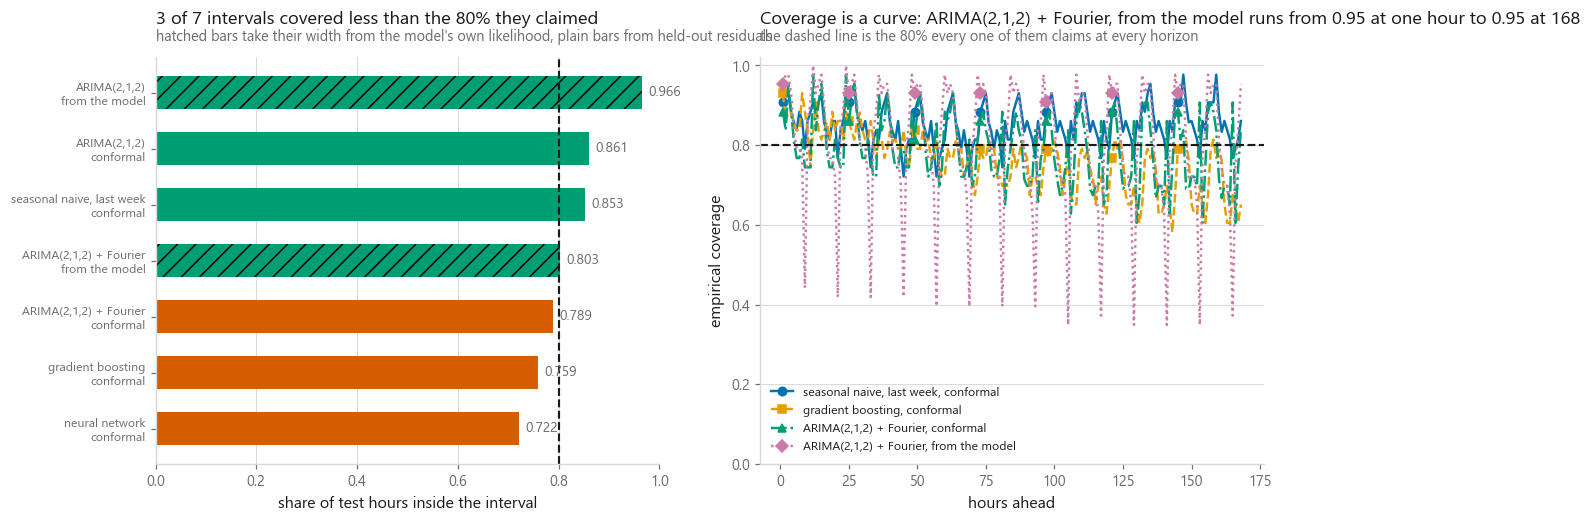

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

ax = axes[0]
order = intervals.sort_values("coverage").reset_index(drop=True)
labels = [f"{r['model']}\n{r['interval']}" for _, r in order.iterrows()]
colours = [style.HIGHLIGHT if r["coverage"] < COVERAGE else style.PALETTE[2]
           for _, r in order.iterrows()]
hatch = ["//" if r["interval"] == "from the model" else "" for _, r in order.iterrows()]
ax.barh(np.arange(len(order)), order["coverage"], color=colours, hatch=hatch, height=0.6)
ax.axvline(COVERAGE, color=style.INK, ls="--", lw=1.4)
for y, value in enumerate(order["coverage"]):
    ax.annotate(f"{value:.3f}", xy=(value, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=style.MUTED)
ax.set_yticks(np.arange(len(order)), labels, fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_xlabel("share of test hours inside the interval")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
style.title(ax, f"{len(under)} of {len(intervals)} intervals covered less than the "
                f"{COVERAGE:.0%} they claimed",
            "hatched bars take their width from the model's own likelihood, plain bars "
            "from held-out residuals")

ax = axes[1]
picks = [name for name in [f"{BASELINE}, conformal", "gradient boosting, conformal",
                           "ARIMA(2,1,2) + Fourier, conformal",
                           "ARIMA(2,1,2) + Fourier, from the model"]
         if name in coverage_curves]
for i, name in enumerate(picks):
    ax.plot(steps + 1, coverage_curves[name], color=SERIES_COLOURS[i % len(SERIES_COLOURS)],
            ls=style.DASHES[i], marker=style.MARKERS[i], markevery=24, lw=1.6, label=name)
ax.axhline(COVERAGE, color=style.INK, ls="--", lw=1.4)
ax.set_xlabel("hours ahead")
ax.set_ylabel("empirical coverage")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", fontsize=8)
drift = coverage_curves[picks[-1]]
style.title(ax, f"Coverage is a curve: {picks[-1]} runs from {drift[0]:.2f} at one hour "
                f"to {drift[WEEK - 1]:.2f} at {WEEK}",
            f"the dashed line is the {COVERAGE:.0%} every one of them claims at every horizon")

style.save(fig, FIG / "fig-04-interval-coverage.png")

One thing to hold onto from that table. A wide interval covers well and says
nothing, so coverage has to be read next to width. An interval that covers its
claim by being twice as wide as another one has not won anything, and the width
column is there so the comparison cannot be made on coverage alone.

### One forecast, drawn

The last figure is a single origin from the test block, so the numbers above
have something to be a picture of.

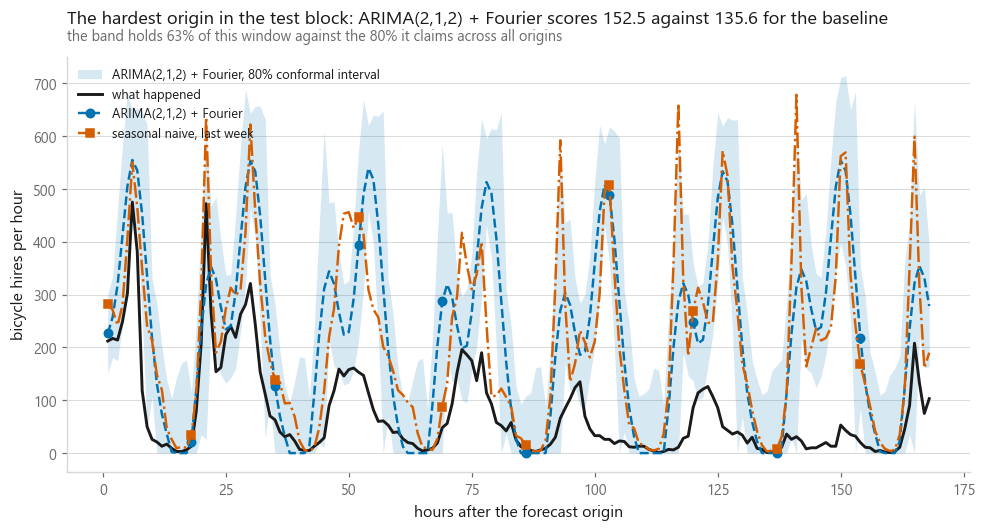

In [18]:
pick = int(np.argmax([mae(test_truth[j][test_seen[j]],
                          test_paths[BASELINE][j][test_seen[j]])
                      for j in range(len(test_origins))]))
origin = int(test_origins[pick])
window = np.arange(origin, origin + HORIZON)

fig, ax = plt.subplots(figsize=(10.6, 4.9))
best_fitted = min(fitted_names, key=lambda n: curves[n][WEEK - 1])
half = conformal_halfwidths(best_fitted)
ax.fill_between(np.arange(1, HORIZON + 1),
                np.maximum(test_paths[best_fitted][pick] - half, 0.0),
                test_paths[best_fitted][pick] + half,
                color=style.PALETTE[0], alpha=0.16, linewidth=0,
                label=f"{best_fitted}, {COVERAGE:.0%} conformal interval")
ax.plot(np.arange(1, HORIZON + 1), counts[window], color=style.INK, lw=1.9,
        label="what happened")
for i, name in enumerate([best_fitted, BASELINE]):
    ax.plot(np.arange(1, HORIZON + 1), test_paths[name][pick],
            color=[style.PALETTE[0], style.HIGHLIGHT][i], ls=["--", "-."][i],
            marker=style.MARKERS[i], markevery=17, lw=1.6, label=name)
ax.set_xlabel("hours after the forecast origin")
ax.set_ylabel("bicycle hires per hour")
ax.legend(loc="upper left", fontsize=8.5)
inside = ((counts[window] >= test_paths[best_fitted][pick] - half)
          & (counts[window] <= test_paths[best_fitted][pick] + half))
style.title(ax, f"The hardest origin in the test block: {best_fitted} scores "
                f"{mae(counts[window], test_paths[best_fitted][pick]):.1f} against "
                f"{mae(counts[window], test_paths[BASELINE][pick]):.1f} for the baseline",
            f"the band holds {inside.mean():.0%} of this window against the "
            f"{COVERAGE:.0%} it claims across all origins")
style.save(fig, FIG / "fig-05-a-forecast.png")

## 7. When it wins, when it loses

The printed tables above answer this by themselves, so here is what I would
carry to the next series rather than a summary of the numbers.

**The baseline is the experiment.** Every score in this chapter changed meaning
once the seasonal naive row was next to it, and on the longest horizon the
fitted-model count printed in section 5 is the result I did not expect when I
started. A forecast that copies last week has no parameters, no training time
and no failure modes, and it does not degrade with the horizon because it is
never applied to its own output.

**ARIMA's problem here is not that it is old.** Section 3 showed by hand where
a stationary autoregression sends its long forecasts, and section 4 measured
what happens when the same model is given the calendar as regressors. Compare
the two ARIMA rows in the horizon table before deciding ARIMA lost. One of them
was asked to represent a daily cycle with no way to know the time.

**What the machine learning models bought was the short horizon.** They have
more features than ARIMA and a much cheaper fit than a seasonal state space,
and the horizon table says where that stops paying. That crossing point is the
number to quote when someone asks whether a model is worth deploying, because
it is the only one that depends on how far ahead the decision actually is.

**A neural network is not the answer to a series this size.** It was given the
same features as the gradient booster on the same rows and its printed scores
are next to them. Deep sequence models earn their place on many related series
at once, where they can share structure across them, and one series of a few
thousand hourly points is not that setting.

**An interval that under-covers is worse than no interval.** The coverage table
says which of these intervals told the truth. A model-based interval inherits
every assumption the model made about its residuals, and the conformal version
only inherits the assumption that the calibration block resembles the test
block, which for a time series is itself a claim worth checking.

## Cheat sheet

| | |
|---|---|
| **First thing to fit** | The seasonal naive forecast. Everything else is scored against it, and it takes one line |
| **Split** | Forward in time, always. Never `shuffle=True`, never `KFold`, and turn off any automatic validation split that picks rows at random |
| **Watch out** | `HistGradientBoostingRegressor` enables early stopping above ten thousand rows and calibrates it on a random slice of the future. Set `early_stopping=False` |
| **ARIMA** | `statsmodels.tsa.arima.model.ARIMA`. Cheap, honest intervals, and it flattens to the mean at long horizons unless something carries the season |
| **Two seasonalities** | Fourier regressors as `exog` beat a seasonal order you cannot afford to fit. Pick the number of harmonics by AIC |
| **Feature models** | One function that builds features for training and for forecasting, so the two cannot drift apart. Poison the future with `nan` and check nothing reads it |
| **Multi-step** | Recursive forecasting compounds its own errors. Score every horizon separately and report the one where the model stops beating the baseline |
| **Intervals** | Model-based when you trust the residual assumption, split conformal per horizon when you do not. Report coverage and width together |
| **Metric** | MAE for readability, MASE for comparability. MASE above one means the baseline was cheaper and better |
| **Next** | [Autoencoders](../../10-generative-models/01-autoencoders/), where the target is the input itself |

## What to remember

1. A time series split runs forward. A shuffled split lets a model read
   tomorrow while answering about today, and the score it produces is real
   arithmetic on a question nobody will ask.
2. The seasonal naive forecast is the experiment, not a courtesy. The counts
   printed in sections 4 and 5 say how many fitted models beat it at one hour
   and at one week, and the two counts are not the same.
3. A stationary autoregression decays to the training mean. Section 3 printed
   the half-life, and past it the forecast is a horizontal line through a series
   that is still swinging.
4. Fourier regressors are the practical answer to two seasonal periods at once,
   because a seasonal order long enough to hold a week is not affordable.
5. Recursive multi-step forecasting feeds a model its own output. Error at the
   end of the horizon divided by error at the start is printed for every model,
   and the baseline's version of that ratio is the one to compare against.
6. Sort by the horizon you actually care about. The ranking at one hour and the
   ranking at one week are different rankings.
7. A prediction interval is a claim with a number in it. Count how often it was
   right, per horizon, and read the width beside the coverage so that being wide
   does not look like being correct.
8. Turn off anything that picks a validation slice at random. On a table it is a
   convenience and on a series it is a leak.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [10-01 Autoencoders](../../10-generative-models/01-autoencoders/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#TimeSeries` `#Forecasting` `#ARIMA` `#SeasonalNaive` `#GradientBoosting`
`#ConformalPrediction` `#BikeSharing` `#Statsmodels` `#ScikitLearn` `#PyTorch`
`#MachineLearning` `#MLTutorial` `#LearnMachineLearning` `#DataScience` `#AI`